# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **Load Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving car data.csv to car data.csv


In [ ]:
df = pd.read_csv("car data.csv")

# **Explore the Dataset**

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.shape

(301, 9)

In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


# **Check Duplicate Records**

In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df.drop_duplicates(inplace=True)

# **Feature Engineering**

In [ ]:
df["Car_Age"] = 2024 - df["Year"]

In [ ]:
df.drop("Year", axis=1, inplace=True)

# **Encode Categorical Columns**

In [ ]:
le = LabelEncoder()

df["Car_Name"] = le.fit_transform(df["Car_Name"])
df["Fuel_Type"] = le.fit_transform(df["Fuel_Type"])
df["Selling_type"] = le.fit_transform(df["Selling_type"])
df["Transmission"] = le.fit_transform(df["Transmission"])

# **Exploratory Data Analysis (EDA)**

# **Correlation Heatmap**

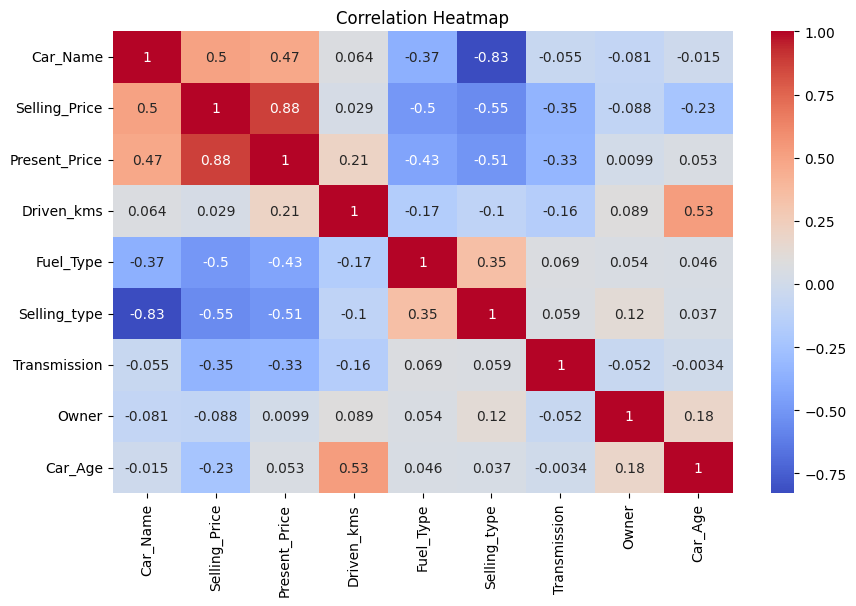

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# **Selling Price Distribution**

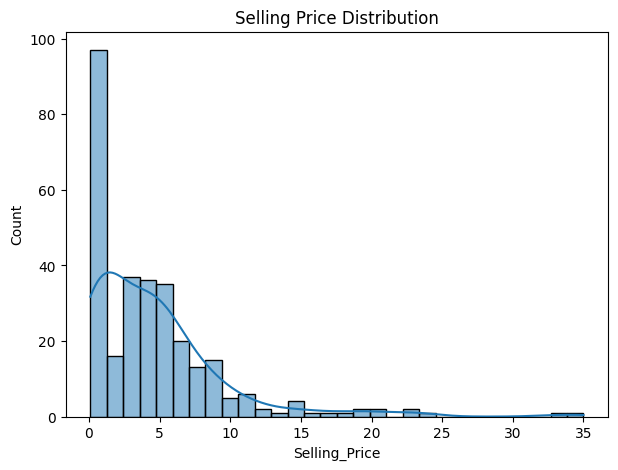

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df["Selling_Price"], bins=30, kde=True)
plt.title("Selling Price Distribution")
plt.show()

# **Fuel Type Count**

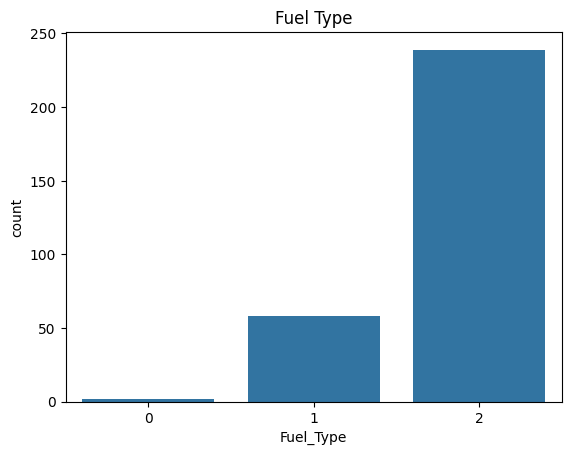

In [ ]:
sns.countplot(x="Fuel_Type", data=df)
plt.title("Fuel Type")
plt.show()

# **Transmission Count**

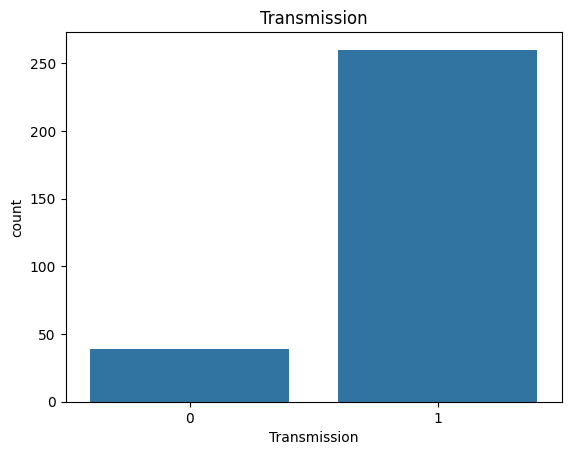

In [ ]:
sns.countplot(x="Transmission", data=df)
plt.title("Transmission")
plt.show()

# **Present Price vs Selling Price**

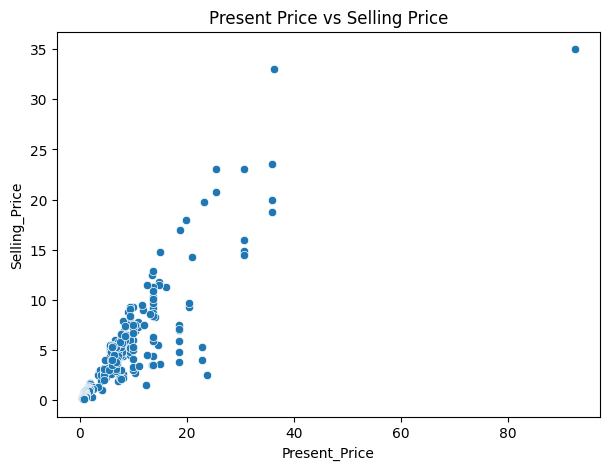

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Present_Price", y="Selling_Price", data=df)
plt.title("Present Price vs Selling Price")
plt.show()

# **Car Age vs Selling Price**

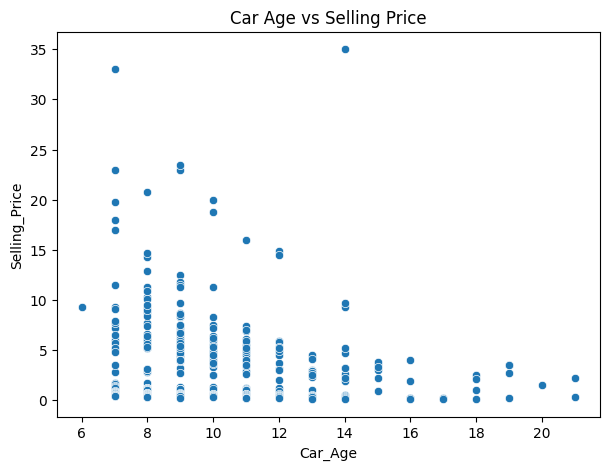

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Car_Age", y="Selling_Price", data=df)
plt.title("Car Age vs Selling Price")
plt.show()

# **Define Features and Target**

In [ ]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

# **Split Dataset**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Train Linear Regression**

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

# **Predict**

In [ ]:
y_pred = lr.predict(X_test)

# **Evaluate Model**

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.5719610024168307
RMSE: 2.61355472065175
R2 Score: 0.7349707530639443


# **Train Random Forest**

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# **Evaluate Random Forest**

In [ ]:
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

MAE: 1.2877233333333338
RMSE: 3.1614950755404743
R2 Score: 0.6121930151298915


# **Actual vs Predicted Graph**

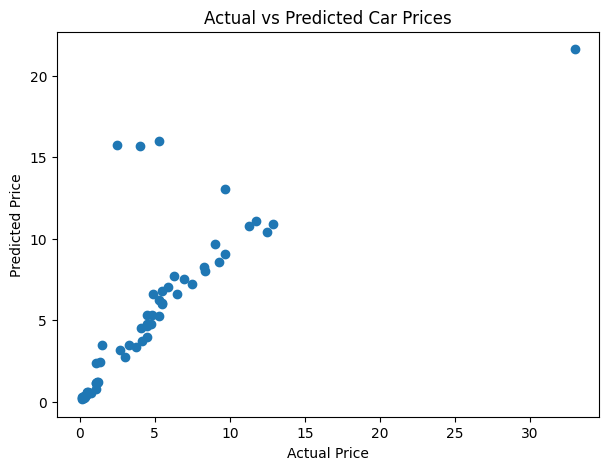

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

# **Conclusion**
The dataset contains 301 car records with 9 features.
No missing values were found.
A new feature (Car_Age) was created to improve prediction.
Categorical features were encoded using LabelEncoder.
Exploratory Data Analysis showed that Present Price has a strong positive relationship with Selling Price.
Both Linear Regression and Random Forest Regressor were trained.
Compare their evaluation metrics and mention which model performed better.
The final model can estimate the selling price of a used car based on its features.